In [2]:
#Robustness test
#Long Only

In [ ]:
!pip install nelson-siegel-svensson
# ============================================================
# PART 1 — 데이터 수집 · 전처리 · 모델 학습
# (v4 + Continual Learning + 32차원 + Vol-Managed + 15Y Rolling)
#
# 유지/변경 내역:
#   - EP, SVAR 매크로 변수 포함 유지 (MACRO_DIM = 11)
#   - 트랜스포머/어텐션 차원: embed_dim = 32 / MLP = 16 유지
#   - 고정 롤링 윈도우: Train 데이터를 15년(180개월)으로 고정, 앞부분도 1년씩 이동
#   - [수정 완료] Excess Sharpe Ratio 적용 (Total Sharpe -> Excess Sharpe 최적화)
#   - [수정 완료] Test Set Data Leakage 방지 (미래 데이터 참조 원천 차단)
#   - [추가 수정] 방어적 Vol-Managed 로직: 변동성이 타겟(10%)보다 클 때만 줄이고, 작아도 늘리진 않음 (max=1.0)
#   - [자산 추가] 단기 회사채(VFSTX) 추가 (총 7자산)
# ============================================================

import pandas as pd
import pandas_datareader.data as web
import yfinance as yf
import numpy as np
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"기기: {device} | 7자산 롱온리 모델 (32d + Defensive Vol-Managed + Rolling) 시작...\n")

# ----------------------------------------------------------
# 전역 상수
# ----------------------------------------------------------
NUM_ASSETS    = 7
MACRO_DIM     = 11
BASE_LR       = 1e-4
WARMUP_EPOCHS = 30
MAX_EPOCHS    = 100
PATIENCE      = 10
WINDOW_SIZE   = 240   # Train 학습 기간 고정: 20년 (240개월)
TARGET_VOL    = 0.10  # Volatility Managed 타겟 연 변동성 (10%)

ASSET_COLS = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
              'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

MACRO_COLS = ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR',
              'SP500_RET', 'INFLATION_YoY', 'UNRATE',
              'Beta1', 'Beta2', 'Beta3']

REW_COLS   = ['REWARD_TREAS_S', 'REWARD_TREAS_M', 'REWARD_TREAS_L',
              'REWARD_CORP_M',  'REWARD_CORP_L',  'REWARD_HY', 'REWARD_CORP_S']

NORM_COLS  = ASSET_COLS + MACRO_COLS

# ==========================================
# 1. 뱅가드 펀드 7종 수익률 (Yahoo Finance)
# ==========================================
etf_tickers  = ['VFISX', 'VFITX', 'VUSTX', 'VFICX', 'VWESX', 'VWEHX', 'VFSTX']
asset_names7 = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
                'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

print("1. Yahoo Finance 데이터 다운로드 중...")
df_raw = yf.download(etf_tickers, start='1990-01-01', end='2025-12-31', progress=False)

try:
    df_etf = df_raw['Adj Close'].resample('ME').last()
except KeyError:
    df_etf = df_raw['Close'].resample('ME').last()

if df_etf.index.tz is not None:
    df_etf.index = df_etf.index.tz_localize(None)
df_etf.index = df_etf.index.to_period('M')

df_portfolio = pd.DataFrame(index=df_etf.index)
for col, ticker in zip(asset_names7, etf_tickers):
    # 수익률을 bps 단위로 변환 (* 10000)
    df_portfolio[col] = df_etf[ticker].pct_change() * 10000

df_portfolio = df_portfolio.dropna()

for col in asset_names7:
    df_portfolio[col.replace('TR_', 'REWARD_')] = df_portfolio[col].shift(-1)

print(f" -> 7개 ETF 로드 완료 (길이: {len(df_portfolio)}개월)")

# ==========================================
# 2. FRED: CPI · UNRATE
# ==========================================
print("2. FRED 실물지표 로드 중...")
df_fred_raw = web.DataReader(
    ['CPIAUCSL', 'UNRATE'], 'fred', '1990-01-01', '2025-12-31'
).resample('ME').last()
df_fred_raw.index = df_fred_raw.index.to_period('M')

df_fred = pd.DataFrame(index=df_fred_raw.index)

df_fred['INFLATION_YoY'] = df_fred_raw['CPIAUCSL'].pct_change(12) * 100
df_fred['INFLATION_YoY'] = df_fred['INFLATION_YoY'].shift(1)

df_fred['UNRATE'] = df_fred_raw['UNRATE'].shift(1)

print(f" -> FRED 로드 완료 (길이: {len(df_fred)}개월)")

# ==========================================
# 3. Goyal-Welch CSV
# ==========================================
print("3. Goyal-Welch CSV 로드 중...")
try:
    import os
    _cands = ['../data/PredictorData2024_monthly.csv',   # repo에서 로컬 실행
              'data/PredictorData2024_monthly.csv',
              'PredictorData2024_monthly.csv']             # Colab에 직접 업로드한 경우
    # 로컬 파일이 없으면 (예: Colab에서 GitHub로 바로 연 경우) repo의 raw 파일을 직접 읽음
    file_path = next((p for p in _cands if os.path.exists(p)),
                     'https://raw.githubusercontent.com/parkjunhee-kk/Bond-Portfolio-optimization-with-Attention/main/data/PredictorData2024_monthly.csv')
    gw_df = pd.read_csv(file_path)
    gw_df['date'] = (pd.to_datetime(gw_df['yyyymm'].astype(str), format='%Y%m')
                     + pd.offsets.MonthEnd(0))

    if gw_df['Index'].dtype == 'O':
        gw_df['Index'] = gw_df['Index'].astype(str).str.replace(',', '').astype(float)

    gw_df['EP']            = np.log(gw_df['E12'] / gw_df['Index'])
    gw_df['SPREAD_10Y_3M'] = gw_df['lty'] - gw_df['tbl']
    gw_df['DFY']           = gw_df['BAA'] - gw_df['AAA']
    gw_df['SP500_RET']     = gw_df['Index'].pct_change()

    gw_macro = gw_df[['date', 'tbl', 'SPREAD_10Y_3M', 'DFY', 'EP', 'svar', 'SP500_RET']].copy()
    gw_macro.rename(columns={'tbl': 'TBILL_RATE', 'svar': 'SVAR'}, inplace=True)
    gw_macro.set_index('date', inplace=True)
    gw_macro.index = gw_macro.index.to_period('M')
    print(f" -> CSV 로드 완료 (길이: {len(gw_macro)}개월)")
except Exception as e:
    print(f" CSV 로드 에러: {e}")
    gw_macro = pd.DataFrame()

# ==========================================
# 4. FRED 국채 금리 → Nelson-Siegel Betas
# ==========================================
print("4. 국채 금리 및 Nelson-Siegel 베타 산출 중...")
yield_tickers = ['GS3M','GS6M','GS1','GS2','GS3','GS5','GS7','GS10','GS30']
df_yield = (web.DataReader(yield_tickers, 'fred', '1990-01-01', '2025-12-31')
            .resample('ME').last().ffill())
df_yield.index = df_yield.index.to_period('M')

maturities = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 30.0])

def get_betas(row):
    if row.isna().any():
        row = row.interpolate().bfill().ffill()
    try:
        curve, _ = calibrate_ns_ols(maturities, row.values, tau0=1.0)
        return pd.Series([curve.beta0, curve.beta1, curve.beta2],
                         index=['Beta1', 'Beta2', 'Beta3'])
    except:
        return pd.Series([np.nan, np.nan, np.nan],
                         index=['Beta1', 'Beta2', 'Beta3'])

df_yield_features = df_yield.apply(get_betas, axis=1)
print(f" -> NS 베타 산출 완료 (길이: {len(df_yield_features)}개월)")

# ==========================================
# 5. 전체 데이터 병합
# ==========================================
df_all_period = pd.concat([df_portfolio, gw_macro, df_fred, df_yield_features], axis=1)
df_all_period.index = df_all_period.index.to_timestamp(how='end')
df_all_raw = df_all_period.sort_index()

df_all = df_all_raw.loc['1993-11-01':'2024-12-31']
df_all = df_all.ffill().dropna()

print("=" * 55)
if len(df_all) == 0:
    print("[에러] 병합 후 데이터 0개.")
    raise ValueError("데이터 병합 실패")

df_all['YEAR'] = df_all.index.year
print(f"병합 성공 | 총 {len(df_all)}개월 | "
      f"{df_all.index[0].strftime('%Y-%m')} ~ {df_all.index[-1].strftime('%Y-%m')}")
print(f"자산 {NUM_ASSETS}개 : {ASSET_COLS}")
print(f"매크로 {MACRO_DIM}개: {MACRO_COLS}")
print("=" * 55)

# ==========================================
# 6. 모델 아키텍처 (embed_dim = 32)
# ==========================================
class PortfolioActor(nn.Module):
    def __init__(self, num_assets=NUM_ASSETS, asset_dim=1,
                 macro_dim=MACRO_DIM, embed_dim=32):
        super().__init__()

        self.a_proj = nn.Linear(asset_dim, embed_dim)
        self.a_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.m_proj = nn.Linear(macro_dim, embed_dim)
        self.m_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=2, batch_first=True)
        self.norm       = nn.LayerNorm(embed_dim)

        self.mlp_weight = nn.Sequential(
            nn.Linear(embed_dim + 1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, a_seq, m_seq, w_prev):
        B, L, N, D_a = a_seq.shape

        a_enc = self.a_tf(
            self.a_proj(a_seq.transpose(1, 2).reshape(B * N, L, D_a))
        )[:, -1, :].view(B, N, -1)

        m_enc = self.m_tf(self.m_proj(m_seq))

        m_query  = m_enc[:, -1:, :]
        attn_out, _ = self.cross_attn(query=m_query,
                                      key=a_enc, value=a_enc)
        attn_out = attn_out.expand(-1, N, -1)
        ctx      = self.norm(a_enc + attn_out)

        combined = torch.cat([ctx, w_prev.unsqueeze(-1)], dim=-1)

        # =======================================================
        # [수정 완료] 2 * tanh (롱숏) -> 2 * softmax (2배 레버리지 롱온리)
        # Softmax(dim=-1)을 통해 자산 간 비중 합이 1이 되도록 만들고,
        # 2.0을 곱하여 총 비중이 2.0(2배 레버리지)인 Long-only로 강제합니다.
        # =======================================================
        w_raw = 2.0 * torch.softmax(self.mlp_weight(combined).squeeze(-1), dim=-1)

        # Softmax의 특성상 이미 비중이 모두 양수이고 합이 2.0이므로
        # 기존의 abs().sum()을 이용한 레버리지 기초 캡 로직은 제거했습니다.
        return w_raw

# ==========================================
# 7. 데이터셋 준비 (과거 12개월 수익률 추가 반환)
# ==========================================
def get_dataset_tensors(df, lookback=12):
    a_data = np.stack([df[[c]].values for c in ASSET_COLS], axis=1)
    # 정규화 전의 원본 데이터(RAW)를 활용해 정확한 Volatility 계산용 시퀀스 준비
    raw_a_data = np.stack([df[[c+'_RAW']].values for c in ASSET_COLS], axis=1)

    m_data = df[MACRO_COLS].values
    r_data = df[REW_COLS].values

    a_seq, m_seq, rew, past_r = [], [], [], []
    for i in range(len(df) - lookback):
        a_seq.append(a_data[i:i+lookback])
        m_seq.append(m_data[i:i+lookback])
        rew.append(r_data[i+lookback-1])
        # 직전 12개월의 원본 수익률 (Shape: 12 x 7)
        past_r.append(raw_a_data[i:i+lookback, :, 0])

    return (torch.tensor(np.array(a_seq),  dtype=torch.float32),
            torch.tensor(np.array(m_seq),  dtype=torch.float32),
            torch.tensor(np.array(past_r), dtype=torch.float32),
            torch.tensor(np.array(rew),    dtype=torch.float32))


# ==========================================
# 8. 학습 루프 (Rolling 15년 고정 + Vol-Managed)
# ==========================================
test_years         = range(2016, 2025)
rl_weights_history = []
test_dates_history = []
all_dates          = df_all.index

set_seed(42)
model = PortfolioActor(embed_dim=32).to(device)

for i, target_year in enumerate(test_years):
    mask = (all_dates.year == target_year)
    if not mask.any():
        continue

    test_start = np.where(mask)[0][0]
    val_start  = test_start - 24
    train_end  = val_start

    # [유지] 고정 롤링 윈도우: 15년(180개월) 단위로 꼬리 부분 자르기
    train_start = max(0, train_end - WINDOW_SIZE)

    train_df = df_all.iloc[train_start:train_end].copy()
    val_df   = df_all.iloc[val_start - 12 : val_start + 24].copy()

    # =======================================================
    # [수정 #2] Test Set Data Leakage 방지
    # =======================================================
    target_year_df = df_all[df_all.index.year == target_year]
    lookback_df    = df_all.iloc[test_start - 12 : test_start]
    test_df        = pd.concat([lookback_df, target_year_df]).copy()
    # =======================================================

    # =======================================================
    # [수정 #1] Excess Sharpe 산출을 위한 무위험수익률(bps) 추출
    # =======================================================
    rf_monthly_bps = (train_df['TBILL_RATE'].mean() / 12.0) * 100.0
    # =======================================================

    # 정규화 전 원본 자산 수익률 보존 (Volatility 계산에 필수)
    for df_ in [train_df, val_df, test_df]:
        for c in ASSET_COLS:
            df_[c+'_RAW'] = df_[c]

    # [중요] 롤링될 때마다 매번 새로운 Train 셋으로 정규화
    t_mean = train_df[NORM_COLS].mean()
    t_std  = train_df[NORM_COLS].std().replace(0, 1e-8)
    for df_ in [train_df, val_df, test_df]:
        df_[NORM_COLS] = (df_[NORM_COLS] - t_mean) / t_std

    tr_a, tr_m, tr_past_r, tr_r = get_dataset_tensors(train_df)
    va_a, va_m, va_past_r, va_r = get_dataset_tensors(val_df)
    te_a, te_m, te_past_r, te_r = get_dataset_tensors(test_df)

    current_base_lr = BASE_LR
    optimizer  = torch.optim.Adam(model.parameters(),
                                   lr=current_base_lr,
                                   weight_decay=1e-4)
    best_val   = float('inf')
    no_improve = 0

    print(f"\n[{target_year}] Rolling (20Y) + Continual Learning "
          f"Train: {train_df.index[12].strftime('%Y-%m')}~{train_df.index[-1].strftime('%Y-%m')} | "
          f"Val: {val_df.index[12].strftime('%Y-%m')}~{val_df.index[-1].strftime('%Y-%m')}")

    for epoch in range(MAX_EPOCHS):
        if epoch < WARMUP_EPOCHS:
            current_lr = current_base_lr * (epoch + 1) / WARMUP_EPOCHS
        else:
            progress   = (epoch - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1)
            current_lr = current_base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        # ── Train ──────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        w_prev       = torch.ones(tr_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        returns_list = []

        for t in range(tr_a.size(0)):
            w_raw = model(tr_a[t:t+1].to(device),
                          tr_m[t:t+1].to(device),
                          w_prev[t:t+1])

            # Volatility-Managed Logic
            past_returns = tr_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)

            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            # [핵심 수정]: max=1.0으로 설정하여 변동성이 작을 때 레버리지를 일으켜 늘리지 않음
            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            R_t = torch.sum(w_managed * tr_r[t:t+1].to(device))
            returns_list.append(R_t)

            if t < tr_a.size(0) - 1:
                w_prev[t+1:t+2] = w_managed.detach()

        returns_t = torch.stack(returns_list)

        # =======================================================
        # [수정 #1] Excess Sharpe Ratio (초과 수익률 기준 적용)
        # =======================================================
        excess_returns_t = returns_t - rf_monthly_bps
        mean_r    = excess_returns_t.mean()
        std_r     = excess_returns_t.std() + 1e-6
        loss      = -(mean_r * math.sqrt(12)) / std_r
        # =======================================================

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Validation ─────────────────────────────────────
        model.eval()
        with torch.no_grad():
            vw = torch.ones(va_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
            vr = []
            for t in range(va_a.size(0)):
                w_raw = model(va_a[t:t+1].to(device),
                              va_m[t:t+1].to(device),
                              vw[t:t+1])

                # Validation Vol-Managed Logic
                past_returns = va_past_r[t:t+1].to(device)
                past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
                realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

                # [핵심 수정]: max=1.0
                scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
                w_managed    = w_raw * scale_factor

                vr.append(torch.sum(w_managed * va_r[t:t+1].to(device)))
                if t < va_a.size(0) - 1:
                    vw[t+1:t+2] = w_managed

            vr_t  = torch.stack(vr)

            # =======================================================
            # [수정 #1] Validation에도 Excess Sharpe 반영
            # =======================================================
            excess_vr_t = vr_t - rf_monthly_bps
            vloss = -((excess_vr_t.mean() * math.sqrt(12)) / (excess_vr_t.std() + 1e-6)).item()
            # =======================================================

        improved = (vloss < best_val)
        if improved:
            best_val   = vloss
            no_improve = 0
            torch.save(model.state_dict(), f"best_{target_year}.pth")
        else:
            no_improve += 1

        tag = " ← best" if improved else f" (patience {no_improve}/{PATIENCE})"
        print(f"  ep {epoch+1:3d} | val_sharpe={-vloss:6.4f} | lr={current_lr:.2e}{tag}")

        if no_improve >= PATIENCE:
            print(f"  → Early stop @ epoch {epoch+1}")
            break

    # ── Test ───────────────────────────────────────────────
    model.load_state_dict(torch.load(f"best_{target_year}.pth", map_location=device))
    model.eval()

    with torch.no_grad():
        tw = torch.ones(te_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        for t in range(te_a.size(0)):
            w_raw = model(te_a[t:t+1].to(device),
                          te_m[t:t+1].to(device),
                          tw[t:t+1])

            # Test Vol-Managed Logic
            past_returns = te_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            # [핵심 수정]: max=1.0
            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            # 실제 투자되는 스케일링된 가중치를 보존
            rl_weights_history.append(w_managed.cpu().numpy()[0])
            if t < te_a.size(0) - 1:
                tw[t+1:t+2] = w_managed

    # 정확히 타겟 연도의 Date만 append 되도록 반영 (lookback 길이인 12번째 이후)
    test_dates_history.append(test_df.index[12:])

print("\n[7자산 RL 헤지펀드 v4] 백테스트 완료")
print("  └  Rolling Window | Defensive Vol-Managed (방어적 비중 축소만) | Excess Sharpe 최적화 적용 완료")

기기: cuda | 7자산 롱온리 모델 (32d + Defensive Vol-Managed + Rolling) 시작...

1. Yahoo Finance 데이터 다운로드 중...
 -> 7개 ETF 로드 완료 (길이: 386개월)
2. FRED 실물지표 로드 중...
 -> FRED 로드 완료 (길이: 432개월)
3. Goyal-Welch CSV 로드 중...
 -> CSV 로드 완료 (길이: 1848개월)
4. 국채 금리 및 Nelson-Siegel 베타 산출 중...
 -> NS 베타 산출 완료 (길이: 432개월)
병합 성공 | 총 374개월 | 1993-11 ~ 2024-12
자산 7개 : ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L', 'TR_CORP_M', 'TR_CORP_L', 'TR_HY', 'TR_CORP_S']
매크로 11개: ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR', 'SP500_RET', 'INFLATION_YoY', 'UNRATE', 'Beta1', 'Beta2', 'Beta3']

[2016] Rolling (20Y) + Continual Learning Train: 1995-01~2013-12 | Val: 2014-01~2015-12
  ep   1 | val_sharpe=1.0430 | lr=3.33e-06 ← best
  ep   2 | val_sharpe=1.0433 | lr=6.67e-06 ← best
  ep   3 | val_sharpe=1.0438 | lr=1.00e-05 ← best
  ep   4 | val_sharpe=1.0445 | lr=1.33e-05 ← best
  ep   5 | val_sharpe=1.0454 | lr=1.67e-05 ← best
  ep   6 | val_sharpe=1.0466 | lr=2.00e-05 ← best
  ep   7 | val_sharpe=1.0480 | lr=2.33e-05 ← best
  

Basic MVO 벤치마크 계산 중 (7자산 롱온리 최대 2x 롤링)...

===== 성과 평가 (2016–2024) | 20Y Rolling · Vol-Managed 10% =====

[1. RL Agent (20Y Rolling · Vol-Managed 10% · 32d)]
  누적 수익률 :    35.88%  | 연평균 수익 :    3.86%
  변동성(Std) :     9.48%  | 연 분산     : 0.008981
  샤프 지수   :   0.4054   | 최대 낙폭   :  -30.79%

[2. Basic MVO (Long-Only up to 2x)]
  누적 수익률 :    11.89%  | 연평균 수익 :    1.59%
  변동성(Std) :     8.12%  | 연 분산     : 0.006599
  샤프 지수   :   0.1932   | 최대 낙폭   :  -30.50%

[3. Equal Weight 2x (Leveraged)]
  누적 수익률 :    41.26%  | 연평균 수익 :    4.57%
  변동성(Std) :    12.06%  | 연 분산     : 0.014551
  샤프 지수   :   0.3773   | 최대 낙폭   :  -33.70%



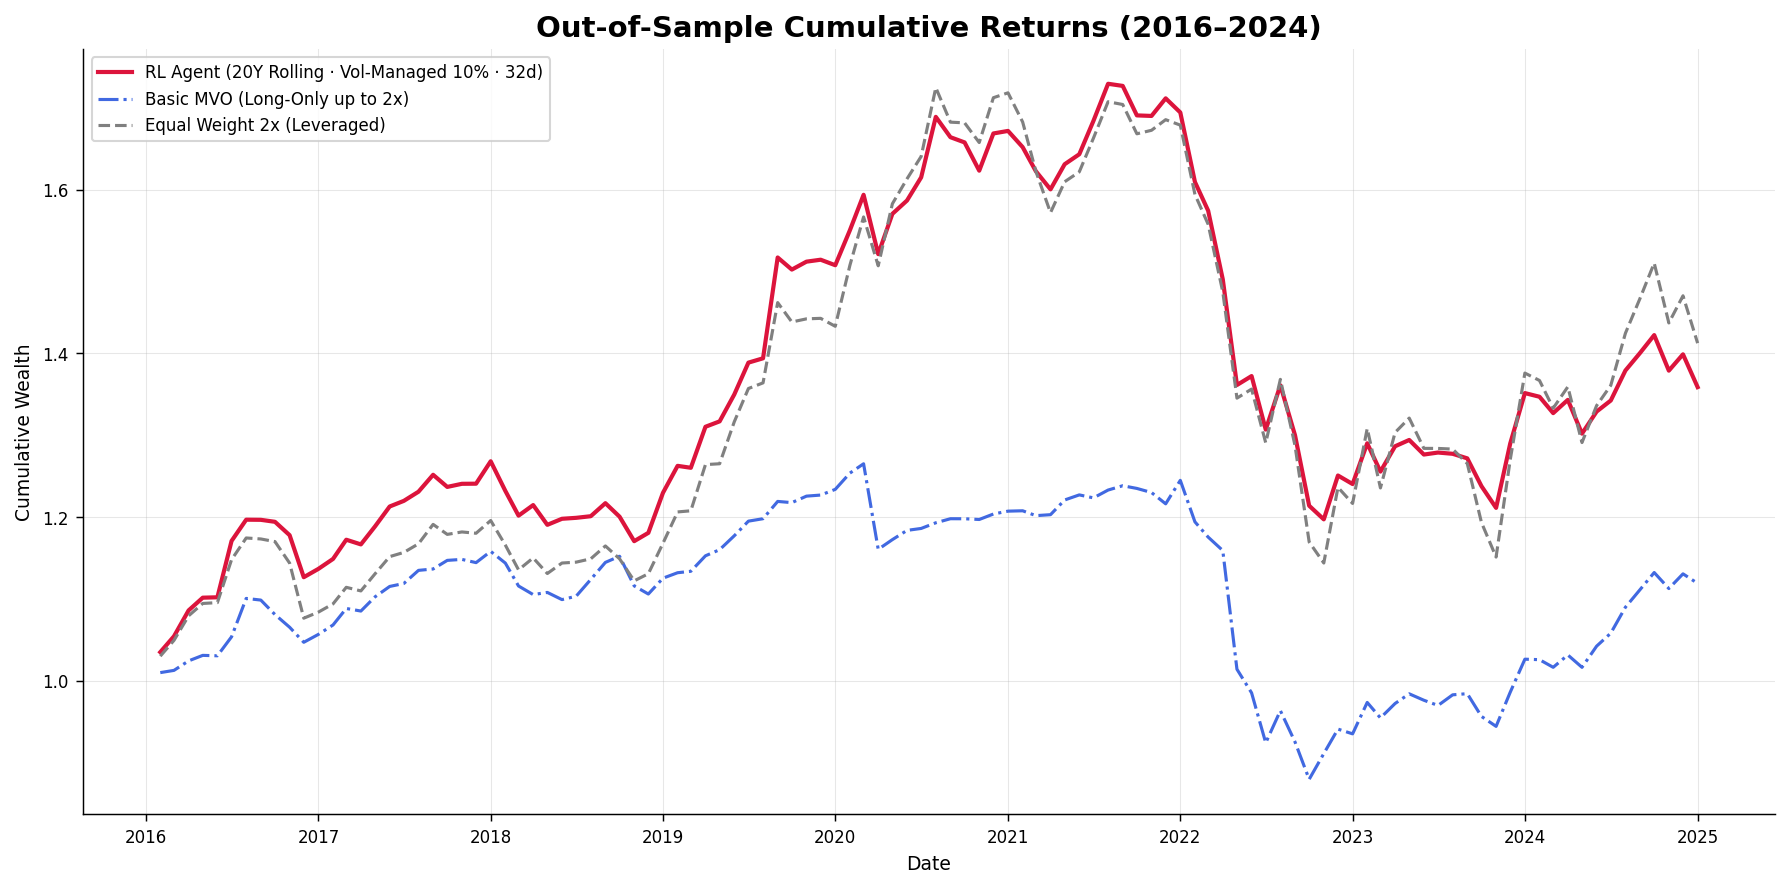


그래프 저장 완료: portfolio_performance_vol_managed.png


In [ ]:
# ============================================================
# PART 2 — 성과 평가 · 벤치마크 비교 · 시각화 (v4 수정판 반영)
#
# ※ Part 1(15Y Rolling + Vol-Managed + 32차원)에서 넘어온 변수:
#    rl_weights_history, test_dates_history,
#    df_all, ASSET_COLS, NUM_ASSETS (=7)
# ============================================================

import scipy.optimize as sco
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import random
import math

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Part 1에서 넘어온 변수 ───────────────────────────────────
final_rl_w  = np.array(rl_weights_history)
final_dates = pd.DatetimeIndex(np.concatenate(test_dates_history))

# [수정] 자산 라벨 7개로 확장 (단기 회사채 CORP_S 추가)
asset_labels = [
    'TREAS_S (Short)',   'TREAS_M (Mid)',    'TREAS_L (Long)',
    'CORP_M (IG Mid)',   'CORP_L (IG Long)', 'HY (High Yield)', 'CORP_S (IG Short)'
]
num_assets = NUM_ASSETS  # 7

# ==========================================
# 1. 실제 수익률 복원 및 무위험 수익률(RF) 추출
# ==========================================
raw_returns      = df_all[ASSET_COLS] / 10000.0
test_raw_returns = raw_returns.loc[final_dates].values
rl_returns       = np.sum(final_rl_w * test_raw_returns, axis=1)

rf_series        = df_all['TBILL_RATE'] / 1200.0
rf_returns_test  = rf_series.loc[final_dates].values

# ==========================================
# 2. 기본 MVO 벤치마크 (7자산, 롱온리 최대 2x 롤링)
# ==========================================
print(f"Basic MVO 벤치마크 계산 중 ({num_assets}자산 롱온리 최대 2x 롤링)...")
mvo_weights_history = []

for date in final_dates:
    lookback_data = raw_returns.loc[:date].iloc[-13:-1].values
    lookback_rf   = rf_series.loc[:date].iloc[-13:-1].values

    cov_matrix = np.cov(lookback_data, rowvar=False)
    mean_ret   = lookback_data.mean(axis=0)
    rf_mean    = lookback_rf.mean()

    def negative_sharpe(w):
        p_ret      = np.sum(mean_ret * w)
        excess_ret = p_ret - rf_mean
        p_vol      = np.sqrt(w @ cov_matrix @ w)
        return -excess_ret / (p_vol + 1e-6)

    # [완성된 롱온리 2배 레버리지 제약]
    # 1. constraints: 전체 비중 합은 최대 2.0 (현금 보유 가능)
    constraints = [
        {'type': 'ineq', 'fun': lambda x: 2.0 - np.sum(x)}
    ]
    # 2. bounds: 숏(음수) 불가. 특정 자산에 최대 2.0(200%) 집중 가능
    bounds     = tuple((0.0, 2.0) for _ in range(num_assets))
    init_guess = [2.0 / num_assets] * num_assets # 초기값도 2배수 기준 분배

    result = sco.minimize(negative_sharpe, init_guess,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    mvo_weights_history.append(result.x)

final_mvo_w = np.array(mvo_weights_history)
mvo_returns = np.sum(final_mvo_w * test_raw_returns, axis=1)

# ==========================================
# 3. Equal Weight 벤치마크 (2배 레버리지 롱온리)
# ==========================================
# [수정] 1/N 에 2.0을 곱하여 정확히 2배 레버리지 롱온리 포지션 구성
eq_returns = np.mean(test_raw_returns, axis=1) * 2.0

# ==========================================
# 4. 성과 지표 산출
# ==========================================
def calc_metrics(returns, rf_returns, name):
    cum_ret        = np.cumprod(1 + returns)
    total_return   = (cum_ret[-1] - 1) * 100
    ann_mean       = np.mean(returns) * 12 * 100
    ann_var        = np.var(returns)  * 12
    ann_std        = np.std(returns)  * np.sqrt(12) * 100
    excess_returns = returns - rf_returns
    sharpe         = (np.mean(excess_returns) * np.sqrt(12)) / (np.std(excess_returns) + 1e-6)
    mdd            = (cum_ret / np.maximum.accumulate(cum_ret) - 1).min() * 100

    print(f"[{name}]")
    print(f"  누적 수익률 : {total_return:8.2f}%  | 연평균 수익 : {ann_mean:7.2f}%")
    print(f"  변동성(Std) : {ann_std:8.2f}%  | 연 분산     : {ann_var:.6f}")
    print(f"  샤프 지수   : {sharpe:8.4f}   | 최대 낙폭   : {mdd:7.2f}%\n")
    return cum_ret

start_yr = final_dates[0].strftime('%Y')
end_yr   = final_dates[-1].strftime('%Y')

print(f"\n===== 성과 평가 ({start_yr}–{end_yr}) | 20Y Rolling · Vol-Managed 10% =====\n")
cum_rl  = calc_metrics(rl_returns,  rf_returns_test,
                       "1. RL Agent (20Y Rolling · Vol-Managed 10% · 32d)")
cum_mvo = calc_metrics(mvo_returns, rf_returns_test,
                       "2. Basic MVO (Long-Only up to 2x)")
cum_eq  = calc_metrics(eq_returns,  rf_returns_test,
                       f"3. Equal Weight 2x (Leveraged)")

# ==========================================
# 5. 시각화 (누적 수익률 1개만 출력)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(final_dates, cum_rl,  lw=2,   color='crimson',
        label='RL Agent (20Y Rolling · Vol-Managed 10% · 32d)')
ax.plot(final_dates, cum_mvo, lw=1.5, color='royalblue', ls='-.',
        label='Basic MVO (Long-Only up to 2x)')
ax.plot(final_dates, cum_eq,  lw=1.5, color='gray',       ls='--',
        label=f'Equal Weight 2x (Leveraged)')

ax.set_title(f'Out-of-Sample Cumulative Returns ({start_yr}–{end_yr})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Wealth')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_performance_vol_managed.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n그래프 저장 완료: portfolio_performance_vol_managed.png")

In [ ]:
# TC 10bp

In [ ]:
!pip install nelson-siegel-svensson
# ============================================================
# PART 1 — 데이터 수집 · 전처리 · 모델 학습
# (v5 + Continual Learning + 32차원 + Vol-Managed + 15Y Rolling + 10bp Transaction Cost)
# ============================================================

import pandas as pd
import pandas_datareader.data as web
import yfinance as yf
import numpy as np
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"기기: {device} | 7자산 롱숏 모델 (32d + Defensive Vol-Managed + Rolling + 10bp TC) 시작...\n")

# ----------------------------------------------------------
# 전역 상수
# ----------------------------------------------------------
NUM_ASSETS    = 7
MACRO_DIM     = 11
BASE_LR       = 1e-5
WARMUP_EPOCHS = 30
MAX_EPOCHS    = 100
PATIENCE      = 10
WINDOW_SIZE   = 240   # Train 학습 기간 고정: 20년 (240개월)
TARGET_VOL    = 0.10  # Volatility Managed 타겟 연 변동성 (10%)

# [수정 완료] 기존 턴오버 페널티 제거 및 실제 10bp 거래비용 설정
TRANSACTION_COST_BPS = 10.0

ASSET_COLS = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
              'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

MACRO_COLS = ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR',
              'SP500_RET', 'INFLATION_YoY', 'UNRATE',
              'Beta1', 'Beta2', 'Beta3']

REW_COLS   = ['REWARD_TREAS_S', 'REWARD_TREAS_M', 'REWARD_TREAS_L',
              'REWARD_CORP_M',  'REWARD_CORP_L',  'REWARD_HY', 'REWARD_CORP_S']

NORM_COLS  = ASSET_COLS + MACRO_COLS

# ==========================================
# 1. 뱅가드 펀드 7종 수익률 (Yahoo Finance)
# ==========================================
etf_tickers  = ['VFISX', 'VFITX', 'VUSTX', 'VFICX', 'VWESX', 'VWEHX', 'VFSTX']
asset_names7 = ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L',
                'TR_CORP_M',  'TR_CORP_L',  'TR_HY', 'TR_CORP_S']

print("1. Yahoo Finance 데이터 다운로드 중...")
df_raw = yf.download(etf_tickers, start='1990-01-01', end='2025-12-31', progress=False)

try:
    df_etf = df_raw['Adj Close'].resample('ME').last()
except KeyError:
    df_etf = df_raw['Close'].resample('ME').last()

if df_etf.index.tz is not None:
    df_etf.index = df_etf.index.tz_localize(None)
df_etf.index = df_etf.index.to_period('M')

df_portfolio = pd.DataFrame(index=df_etf.index)
for col, ticker in zip(asset_names7, etf_tickers):
    # 수익률을 bps 단위로 변환 (* 10000)
    df_portfolio[col] = df_etf[ticker].pct_change() * 10000

df_portfolio = df_portfolio.dropna()

for col in asset_names7:
    df_portfolio[col.replace('TR_', 'REWARD_')] = df_portfolio[col].shift(-1)

print(f" -> 7개 ETF 로드 완료 (길이: {len(df_portfolio)}개월)")

# ==========================================
# 2. FRED: CPI · UNRATE
# ==========================================
print("2. FRED 실물지표 로드 중...")
df_fred_raw = web.DataReader(
    ['CPIAUCSL', 'UNRATE'], 'fred', '1990-01-01', '2025-12-31'
).resample('ME').last()
df_fred_raw.index = df_fred_raw.index.to_period('M')

df_fred = pd.DataFrame(index=df_fred_raw.index)

df_fred['INFLATION_YoY'] = df_fred_raw['CPIAUCSL'].pct_change(12) * 100
df_fred['INFLATION_YoY'] = df_fred['INFLATION_YoY'].shift(1)

df_fred['UNRATE'] = df_fred_raw['UNRATE'].shift(1)

print(f" -> FRED 로드 완료 (길이: {len(df_fred)}개월)")

# ==========================================
# 3. Goyal-Welch CSV
# ==========================================
print("3. Goyal-Welch CSV 로드 중...")
try:
    import os
    _cands = ['../data/PredictorData2024_monthly.csv',   # repo에서 로컬 실행
              'data/PredictorData2024_monthly.csv',
              'PredictorData2024_monthly.csv']             # Colab에 직접 업로드한 경우
    # 로컬 파일이 없으면 (예: Colab에서 GitHub로 바로 연 경우) repo의 raw 파일을 직접 읽음
    file_path = next((p for p in _cands if os.path.exists(p)),
                     'https://raw.githubusercontent.com/parkjunhee-kk/Bond-Portfolio-optimization-with-Attention/main/data/PredictorData2024_monthly.csv')
    gw_df = pd.read_csv(file_path)
    gw_df['date'] = (pd.to_datetime(gw_df['yyyymm'].astype(str), format='%Y%m')
                     + pd.offsets.MonthEnd(0))

    if gw_df['Index'].dtype == 'O':
        gw_df['Index'] = gw_df['Index'].astype(str).str.replace(',', '').astype(float)

    gw_df['EP']            = np.log(gw_df['E12'] / gw_df['Index'])
    gw_df['SPREAD_10Y_3M'] = gw_df['lty'] - gw_df['tbl']
    gw_df['DFY']           = gw_df['BAA'] - gw_df['AAA']
    gw_df['SP500_RET']     = gw_df['Index'].pct_change()

    gw_macro = gw_df[['date', 'tbl', 'SPREAD_10Y_3M', 'DFY', 'EP', 'svar', 'SP500_RET']].copy()
    gw_macro.rename(columns={'tbl': 'TBILL_RATE', 'svar': 'SVAR'}, inplace=True)
    gw_macro.set_index('date', inplace=True)
    gw_macro.index = gw_macro.index.to_period('M')
    print(f" -> CSV 로드 완료 (길이: {len(gw_macro)}개월)")
except Exception as e:
    print(f" CSV 로드 에러: {e}")
    gw_macro = pd.DataFrame()

# ==========================================
# 4. FRED 국채 금리 → Nelson-Siegel Betas
# ==========================================
print("4. 국채 금리 및 Nelson-Siegel 베타 산출 중...")
yield_tickers = ['GS3M','GS6M','GS1','GS2','GS3','GS5','GS7','GS10','GS30']
df_yield = (web.DataReader(yield_tickers, 'fred', '1990-01-01', '2025-12-31')
            .resample('ME').last().ffill())
df_yield.index = df_yield.index.to_period('M')

maturities = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 30.0])

def get_betas(row):
    if row.isna().any():
        row = row.interpolate().bfill().ffill()
    try:
        curve, _ = calibrate_ns_ols(maturities, row.values, tau0=1.0)
        return pd.Series([curve.beta0, curve.beta1, curve.beta2],
                         index=['Beta1', 'Beta2', 'Beta3'])
    except:
        return pd.Series([np.nan, np.nan, np.nan],
                         index=['Beta1', 'Beta2', 'Beta3'])

df_yield_features = df_yield.apply(get_betas, axis=1)
print(f" -> NS 베타 산출 완료 (길이: {len(df_yield_features)}개월)")

# ==========================================
# 5. 전체 데이터 병합
# ==========================================
df_all_period = pd.concat([df_portfolio, gw_macro, df_fred, df_yield_features], axis=1)
df_all_period.index = df_all_period.index.to_timestamp(how='end')
df_all_raw = df_all_period.sort_index()

df_all = df_all_raw.loc['1993-11-01':'2024-12-31']
df_all = df_all.ffill().dropna()

print("=" * 55)
if len(df_all) == 0:
    print("[에러] 병합 후 데이터 0개.")
    raise ValueError("데이터 병합 실패")

df_all['YEAR'] = df_all.index.year
print(f"병합 성공 | 총 {len(df_all)}개월 | "
      f"{df_all.index[0].strftime('%Y-%m')} ~ {df_all.index[-1].strftime('%Y-%m')}")
print(f"자산 {NUM_ASSETS}개 : {ASSET_COLS}")
print(f"매크로 {MACRO_DIM}개: {MACRO_COLS}")
print("=" * 55)

# ==========================================
# 6. 모델 아키텍처 (embed_dim = 32)
# ==========================================
class PortfolioActor(nn.Module):
    def __init__(self, num_assets=NUM_ASSETS, asset_dim=1,
                 macro_dim=MACRO_DIM, embed_dim=32):
        super().__init__()

        self.a_proj = nn.Linear(asset_dim, embed_dim)
        self.a_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.m_proj = nn.Linear(macro_dim, embed_dim)
        self.m_tf   = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                embed_dim, nhead=2, batch_first=True, dropout=0.1),
            num_layers=1)

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=2, batch_first=True)
        self.norm       = nn.LayerNorm(embed_dim)

        self.mlp_weight = nn.Sequential(
            nn.Linear(embed_dim + 1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, a_seq, m_seq, w_prev):
        B, L, N, D_a = a_seq.shape

        a_enc = self.a_tf(
            self.a_proj(a_seq.transpose(1, 2).reshape(B * N, L, D_a))
        )[:, -1, :].view(B, N, -1)

        m_enc = self.m_tf(self.m_proj(m_seq))

        m_query  = m_enc[:, -1:, :]
        attn_out, _ = self.cross_attn(query=m_query,
                                      key=a_enc, value=a_enc)
        attn_out = attn_out.expand(-1, N, -1)
        ctx      = self.norm(a_enc + attn_out)

        combined = torch.cat([ctx, w_prev.unsqueeze(-1)], dim=-1)
        w_raw    = 2.0 * torch.tanh(self.mlp_weight(combined).squeeze(-1))

        # 기본 포트폴리오 가중치 제약 (레버리지 기초 캡)
        gross = w_raw.abs().sum(dim=-1, keepdim=True).clamp(min=1e-6)
        w     = torch.where(gross > 2.0, w_raw * (2.0 / gross), w_raw)
        return w

# ==========================================
# 7. 데이터셋 준비 (과거 12개월 수익률 추가 반환)
# ==========================================
def get_dataset_tensors(df, lookback=12):
    a_data = np.stack([df[[c]].values for c in ASSET_COLS], axis=1)
    # 정규화 전의 원본 데이터(RAW)를 활용해 정확한 Volatility 계산용 시퀀스 준비
    raw_a_data = np.stack([df[[c+'_RAW']].values for c in ASSET_COLS], axis=1)

    m_data = df[MACRO_COLS].values
    r_data = df[REW_COLS].values

    a_seq, m_seq, rew, past_r = [], [], [], []
    for i in range(len(df) - lookback):
        a_seq.append(a_data[i:i+lookback])
        m_seq.append(m_data[i:i+lookback])
        rew.append(r_data[i+lookback-1])
        # 직전 12개월의 원본 수익률 (Shape: 12 x 7)
        past_r.append(raw_a_data[i:i+lookback, :, 0])

    return (torch.tensor(np.array(a_seq),  dtype=torch.float32),
            torch.tensor(np.array(m_seq),  dtype=torch.float32),
            torch.tensor(np.array(past_r), dtype=torch.float32),
            torch.tensor(np.array(rew),    dtype=torch.float32))

# ==========================================
# 8. 학습 루프 (Rolling 15년 고정 + Vol-Managed + 10bp TC)
# ==========================================
test_years         = range(2016, 2025)
rl_weights_history = []
test_dates_history = []
all_dates          = df_all.index

set_seed(42)
model = PortfolioActor(embed_dim=32).to(device)

for i, target_year in enumerate(test_years):
    mask = (all_dates.year == target_year)
    if not mask.any():
        continue

    test_start = np.where(mask)[0][0]
    val_start  = test_start - 24
    train_end  = val_start

    train_start = max(0, train_end - WINDOW_SIZE)

    train_df = df_all.iloc[train_start:train_end].copy()
    val_df   = df_all.iloc[val_start - 12 : val_start + 24].copy()

    target_year_df = df_all[df_all.index.year == target_year]
    lookback_df    = df_all.iloc[test_start - 12 : test_start]
    test_df        = pd.concat([lookback_df, target_year_df]).copy()

    rf_monthly_bps = (train_df['TBILL_RATE'].mean() / 12.0) * 100.0

    for df_ in [train_df, val_df, test_df]:
        for c in ASSET_COLS:
            df_[c+'_RAW'] = df_[c]

    t_mean = train_df[NORM_COLS].mean()
    t_std  = train_df[NORM_COLS].std().replace(0, 1e-8)
    for df_ in [train_df, val_df, test_df]:
        df_[NORM_COLS] = (df_[NORM_COLS] - t_mean) / t_std

    tr_a, tr_m, tr_past_r, tr_r = get_dataset_tensors(train_df)
    va_a, va_m, va_past_r, va_r = get_dataset_tensors(val_df)
    te_a, te_m, te_past_r, te_r = get_dataset_tensors(test_df)

    current_base_lr = BASE_LR
    optimizer  = torch.optim.Adam(model.parameters(),
                                   lr=current_base_lr,
                                   weight_decay=1e-4)
    best_val   = float('inf')
    no_improve = 0

    print(f"\n[{target_year}] Rolling (20Y) + Continual Learning "
          f"Train: {train_df.index[12].strftime('%Y-%m')}~{train_df.index[-1].strftime('%Y-%m')} | "
          f"Val: {val_df.index[12].strftime('%Y-%m')}~{val_df.index[-1].strftime('%Y-%m')}")

    for epoch in range(MAX_EPOCHS):
        if epoch < WARMUP_EPOCHS:
            current_lr = current_base_lr * (epoch + 1) / WARMUP_EPOCHS
        else:
            progress   = (epoch - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1)
            current_lr = current_base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        # ── Train ──────────────────────────────────────────
        model.train()
        optimizer.zero_grad()

        w_prev        = torch.ones(tr_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        returns_list  = []

        for t in range(tr_a.size(0)):
            w_raw = model(tr_a[t:t+1].to(device),
                          tr_m[t:t+1].to(device),
                          w_prev[t:t+1])

            past_returns = tr_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            # Turnover 산출
            r_drift = (tr_past_r[t:t+1, -1, :] / 10000.0).to(device)
            drift_num = w_prev[t:t+1] * (1.0 + r_drift)
            drift_den = 1.0 + torch.sum(w_prev[t:t+1] * r_drift, dim=-1, keepdim=True)
            w_drifted = drift_num / drift_den

            # t시점의 턴오버 발생량 계산
            turnover_t = torch.sum(torch.abs(w_managed - w_drifted))

            # [수정] 총 수익률(Gross) 계산 후 거래비용 차감하여 순수익률(Net) 기록
            gross_r_t = torch.sum(w_managed * tr_r[t:t+1].to(device))
            net_r_t   = gross_r_t - (turnover_t * TRANSACTION_COST_BPS)
            returns_list.append(net_r_t)

            if t < tr_a.size(0) - 1:
                w_prev[t+1:t+2] = w_managed.detach()

        returns_t = torch.stack(returns_list)

        # [수정] 거래비용이 이미 차감된 순수익률 기반의 온전한 Sharpe Ratio로 Loss 산출
        excess_returns_t = returns_t - rf_monthly_bps
        mean_r = excess_returns_t.mean()
        std_r  = excess_returns_t.std() + 1e-6
        sharpe = (mean_r * math.sqrt(12)) / std_r

        # 샤프지수 극대화 (부호 반전)
        loss = -sharpe

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Validation ─────────────────────────────────────
        model.eval()
        with torch.no_grad():
            vw = torch.ones(va_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
            vr = []

            for t in range(va_a.size(0)):
                w_raw = model(va_a[t:t+1].to(device),
                              va_m[t:t+1].to(device),
                              vw[t:t+1])

                past_returns = va_past_r[t:t+1].to(device)
                past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
                realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

                scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
                w_managed    = w_raw * scale_factor

                # Val Turnover 산출 및 거래비용 차감
                r_drift = (va_past_r[t:t+1, -1, :] / 10000.0).to(device)
                drift_num = vw[t:t+1] * (1.0 + r_drift)
                drift_den = 1.0 + torch.sum(vw[t:t+1] * r_drift, dim=-1, keepdim=True)
                w_drifted = drift_num / drift_den

                v_turnover_t = torch.sum(torch.abs(w_managed - w_drifted))

                v_gross_r_t = torch.sum(w_managed * va_r[t:t+1].to(device))
                v_net_r_t   = v_gross_r_t - (v_turnover_t * TRANSACTION_COST_BPS)
                vr.append(v_net_r_t)

                if t < va_a.size(0) - 1:
                    vw[t+1:t+2] = w_managed

            vr_t = torch.stack(vr)

            # Val 평가도 거래비용 차감 후 순수익률 기준 샤프지수
            excess_vr_t = vr_t - rf_monthly_bps
            v_sharpe = (excess_vr_t.mean() * math.sqrt(12)) / (excess_vr_t.std() + 1e-6)
            vloss = -v_sharpe.item()

        improved = (vloss < best_val)
        if improved:
            best_val   = vloss
            no_improve = 0
            torch.save(model.state_dict(), f"best_{target_year}.pth")
        else:
            no_improve += 1

        tag = " ← best" if improved else f" (patience {no_improve}/{PATIENCE})"
        print(f"  ep {epoch+1:3d} | val_net_sharpe={-vloss:6.4f} | lr={current_lr:.2e}{tag}")

        if no_improve >= PATIENCE:
            print(f"  → Early stop @ epoch {epoch+1}")
            break

    # ── Test ───────────────────────────────────────────────
    model.load_state_dict(torch.load(f"best_{target_year}.pth", map_location=device))
    model.eval()

    with torch.no_grad():
        tw = torch.ones(te_a.size(0), NUM_ASSETS).to(device) / NUM_ASSETS
        for t in range(te_a.size(0)):
            w_raw = model(te_a[t:t+1].to(device),
                          te_m[t:t+1].to(device),
                          tw[t:t+1])

            # Test Vol-Managed Logic
            past_returns = te_past_r[t:t+1].to(device)
            past_port_returns = torch.sum(w_raw.unsqueeze(1) * past_returns, dim=-1)
            realized_vol = (past_port_returns.std(dim=-1) * math.sqrt(12) / 10000.0) + 1e-6

            scale_factor = torch.clamp(TARGET_VOL / realized_vol, min=0.1, max=1.0).unsqueeze(-1)
            w_managed    = w_raw * scale_factor

            rl_weights_history.append(w_managed.cpu().numpy()[0])
            if t < te_a.size(0) - 1:
                tw[t+1:t+2] = w_managed

    test_dates_history.append(test_df.index[12:])

print("\n[7자산 RL 헤지펀드 v5] 백테스트 완료")
print("  └  Rolling Window | Defensive Vol-Managed | 10bp Transaction Cost 적용 완료")

기기: cuda | 7자산 롱숏 모델 (32d + Defensive Vol-Managed + Rolling + 10bp TC) 시작...

1. Yahoo Finance 데이터 다운로드 중...
 -> 7개 ETF 로드 완료 (길이: 386개월)
2. FRED 실물지표 로드 중...
 -> FRED 로드 완료 (길이: 432개월)
3. Goyal-Welch CSV 로드 중...
 -> CSV 로드 완료 (길이: 1848개월)
4. 국채 금리 및 Nelson-Siegel 베타 산출 중...
 -> NS 베타 산출 완료 (길이: 432개월)
병합 성공 | 총 374개월 | 1993-11 ~ 2024-12
자산 7개 : ['TR_TREAS_S', 'TR_TREAS_M', 'TR_TREAS_L', 'TR_CORP_M', 'TR_CORP_L', 'TR_HY', 'TR_CORP_S']
매크로 11개: ['TBILL_RATE', 'SPREAD_10Y_3M', 'DFY', 'EP', 'SVAR', 'SP500_RET', 'INFLATION_YoY', 'UNRATE', 'Beta1', 'Beta2', 'Beta3']

[2016] Rolling (20Y) + Continual Learning Train: 1995-01~2013-12 | Val: 2014-01~2015-12
  ep   1 | val_net_sharpe=1.0002 | lr=3.33e-07 ← best
  ep   2 | val_net_sharpe=1.0002 | lr=6.67e-07 (patience 1/10)
  ep   3 | val_net_sharpe=1.0001 | lr=1.00e-06 (patience 2/10)
  ep   4 | val_net_sharpe=1.0001 | lr=1.33e-06 (patience 3/10)
  ep   5 | val_net_sharpe=1.0000 | lr=1.67e-06 (patience 4/10)
  ep   6 | val_net_sharpe=0.9999 | lr

Basic MVO 벤치마크 계산 중 (7자산 롱숏 롤링)...

===== 성과 평가 (2016–2024) | 20Y Rolling · 10bp TC 차감 완료 =====

[1. RL Agent (Net, Vol-Managed 10%)]
  누적 순수익률:    40.09%  | 연평균 순수익:    4.10%
  변동성(Std)  :     8.37%  | 연 분산      : 0.007000
  샤프 지수    :   0.4876   | 최대 낙폭    :  -21.56%
  월평균 턴오버:    60.99%

[2. Basic MVO (Net, Long-Short 2x)]
  누적 순수익률:    -1.81%  | 연평균 순수익:   -0.14%
  변동성(Std)  :     3.44%  | 연 분산      : 0.001182
  샤프 지수    :  -0.0473   | 최대 낙폭    :  -18.93%
  월평균 턴오버:    88.28%

[3. Equal Weight 1/7 (Net)]
  누적 순수익률:    20.69%  | 연평균 순수익:    2.27%
  변동성(Std)  :     6.03%  | 연 분산      : 0.003637
  샤프 지수    :   0.3736   | 최대 낙폭    :  -18.18%
  월평균 턴오버:     1.01%



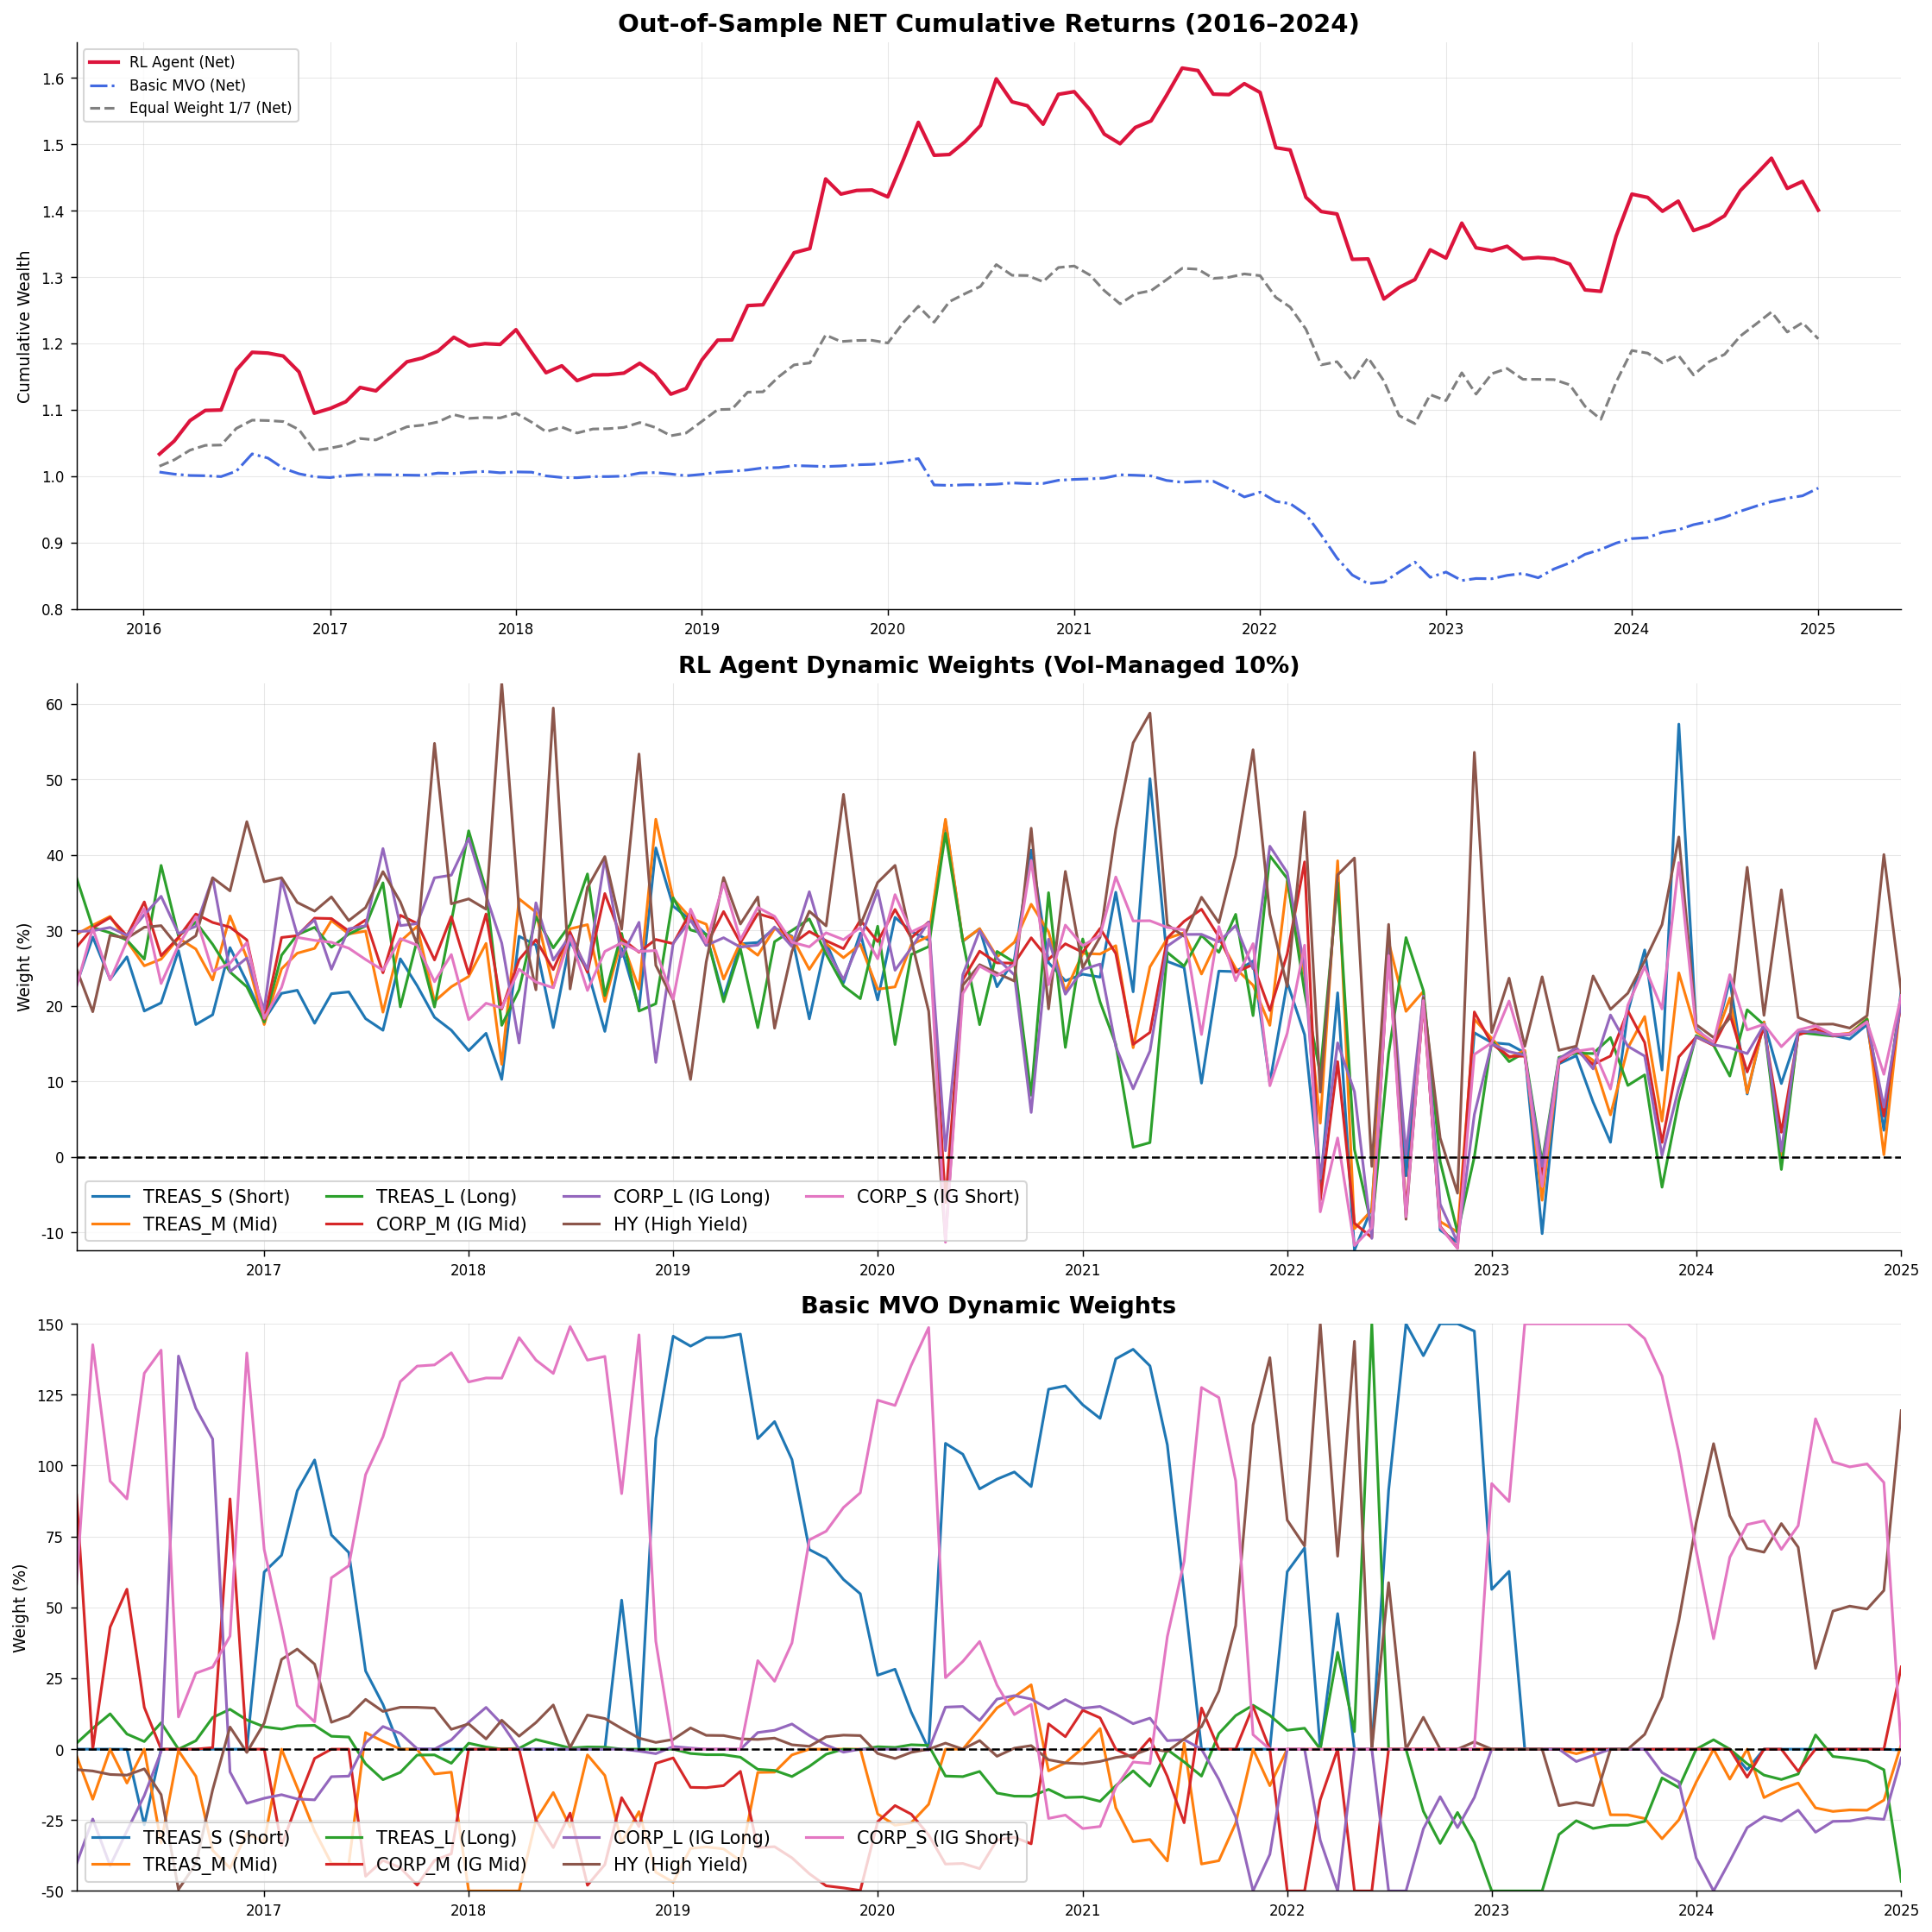


그래프 저장 완료: portfolio_performance_net_returns.png


In [ ]:
# ============================================================
# PART 2 — 성과 평가 · 벤치마크 비교 · 시각화 (Net Return + Turnover 추가)
#
# ※ Part 1(15Y Rolling + Vol-Managed + 32차원 + 10bp TC)에서 넘어온 변수:
#    rl_weights_history, test_dates_history,
#    df_all, ASSET_COLS, NUM_ASSETS (=7)
# ============================================================

import scipy.optimize as sco
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import random
import math

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ----------------------------------------------------------
# [신규] 거래비용 상수 (Part 1과 동일하게 맞춤)
# ----------------------------------------------------------
TRANSACTION_COST_BPS = 10.0
TC_DECIMAL = TRANSACTION_COST_BPS / 10000.0

# ── Part 1에서 넘어온 변수 ───────────────────────────────────
final_rl_w  = np.array(rl_weights_history)
final_dates = pd.DatetimeIndex(np.concatenate(test_dates_history))

# [수정] 자산 라벨 7개로 확장 (단기 회사채 CORP_S 추가)
asset_labels = [
    'TREAS_S (Short)',   'TREAS_M (Mid)',    'TREAS_L (Long)',
    'CORP_M (IG Mid)',   'CORP_L (IG Long)', 'HY (High Yield)', 'CORP_S (IG Short)'
]
num_assets = NUM_ASSETS  # 7

# ==========================================
# 1. 실제 수익률 복원 및 무위험 수익률(RF) 추출
# ==========================================
# Part 1에서 bps(*10000) 단위였으므로 다시 소수점 단위로 원복
raw_returns      = df_all[ASSET_COLS] / 10000.0
test_raw_returns = raw_returns.loc[final_dates].values

rf_series        = df_all['TBILL_RATE'] / 1200.0
rf_returns_test  = rf_series.loc[final_dates].values

# ==========================================
# [신규] 순수익률(Net Return) 및 턴오버 계산 함수
# ==========================================
def calc_net_returns_and_turnover(weights, returns_data, tc_decimal):
    """
    주어진 비중과 자산 수익률을 바탕으로 시장 가격 변동(Drift)을 반영한
    실제 턴오버와 거래비용이 차감된 순수익률을 계산합니다.
    """
    n_periods = len(weights)
    net_returns = np.zeros(n_periods)
    turnovers = np.zeros(n_periods)

    # 첫 달 리밸런싱 전의 초기 비중은 동일 비중(1/N)으로 가정
    w_prev = np.ones(num_assets) / num_assets

    for t in range(n_periods):
        # 1. 가격 변동에 따른 기존 비중의 이동(Drift) 계산
        if t == 0:
            w_drifted = w_prev
        else:
            r_prev = returns_data[t-1]
            drift_num = w_prev * (1.0 + r_prev)
            drift_den = 1.0 + np.sum(w_prev * r_prev)
            w_drifted = drift_num / drift_den

        # 2. 이번 달 타겟 비중
        w_target = weights[t]

        # 3. 턴오버 계산 (타겟 비중과 이동된 비중의 절대 차이 합)
        turnover_t = np.sum(np.abs(w_target - w_drifted))
        turnovers[t] = turnover_t

        # 4. 거래비용 차감된 Net Return 계산
        gross_ret = np.sum(w_target * returns_data[t])
        net_ret   = gross_ret - (turnover_t * tc_decimal)

        net_returns[t] = net_ret
        w_prev = w_target

    return net_returns, turnovers

# ==========================================
# 2. RL 모델 Net Return 계산
# ==========================================
rl_net_returns, rl_turnovers = calc_net_returns_and_turnover(final_rl_w, test_raw_returns, TC_DECIMAL)

# ==========================================
# 3. 기본 MVO 벤치마크 (7자산, 롱숏 2x 롤링, 표본 공분산 사용)
# ==========================================
print(f"Basic MVO 벤치마크 계산 중 ({num_assets}자산 롱숏 롤링)...")
mvo_weights_history = []

for date in final_dates:
    lookback_data = raw_returns.loc[:date].iloc[-13:-1].values
    lookback_rf   = rf_series.loc[:date].iloc[-13:-1].values

    cov_matrix = np.cov(lookback_data, rowvar=False)
    mean_ret   = lookback_data.mean(axis=0)
    rf_mean    = lookback_rf.mean()

    def negative_sharpe(w):
        p_ret      = np.sum(mean_ret * w)
        excess_ret = p_ret - rf_mean
        p_vol      = np.sqrt(w @ cov_matrix @ w)
        return -excess_ret / (p_vol + 1e-6)

    constraints = [
        {'type': 'eq',   'fun': lambda x: np.sum(x) - 1.0},
        {'type': 'ineq', 'fun': lambda x: 2.0 - np.sum(np.abs(x))},
    ]
    bounds     = tuple((-0.5, 1.5) for _ in range(num_assets))
    init_guess = [1.0 / num_assets] * num_assets

    result = sco.minimize(negative_sharpe, init_guess,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    mvo_weights_history.append(result.x)

final_mvo_w = np.array(mvo_weights_history)
mvo_net_returns, mvo_turnovers = calc_net_returns_and_turnover(final_mvo_w, test_raw_returns, TC_DECIMAL)

# ==========================================
# 4. Equal Weight 벤치마크 (1/7)
# ==========================================
# 매월 1/N로 리밸런싱한다고 가정하여 동일하게 비용 차감
eq_weights = np.ones((len(test_raw_returns), num_assets)) / num_assets
eq_net_returns, eq_turnovers = calc_net_returns_and_turnover(eq_weights, test_raw_returns, TC_DECIMAL)


# ==========================================
# 5. 성과 지표 산출 (Net Return + Turnover 기준)
# ==========================================
def calc_metrics(returns, rf_returns, turnovers, name):
    cum_ret        = np.cumprod(1 + returns)
    total_return   = (cum_ret[-1] - 1) * 100
    ann_mean       = np.mean(returns) * 12 * 100
    ann_var        = np.var(returns)  * 12
    ann_std        = np.std(returns)  * np.sqrt(12) * 100
    excess_returns = returns - rf_returns
    sharpe         = (np.mean(excess_returns) * np.sqrt(12)) / (np.std(excess_returns) + 1e-6)
    mdd            = (cum_ret / np.maximum.accumulate(cum_ret) - 1).min() * 100

    # 턴오버는 비율(%)로 변환하여 표시 (예: 0.5 = 50% 턴오버)
    mean_turnover  = np.mean(turnovers) * 100

    print(f"[{name}]")
    print(f"  누적 순수익률: {total_return:8.2f}%  | 연평균 순수익: {ann_mean:7.2f}%")
    print(f"  변동성(Std)  : {ann_std:8.2f}%  | 연 분산      : {ann_var:.6f}")
    print(f"  샤프 지수    : {sharpe:8.4f}   | 최대 낙폭    : {mdd:7.2f}%")
    print(f"  월평균 턴오버: {mean_turnover:8.2f}%\n")
    return cum_ret

start_yr = final_dates[0].strftime('%Y')
end_yr   = final_dates[-1].strftime('%Y')

print(f"\n===== 성과 평가 ({start_yr}–{end_yr}) | 20Y Rolling · 10bp TC 차감 완료 =====\n")
cum_rl  = calc_metrics(rl_net_returns,  rf_returns_test, rl_turnovers,
                       "1. RL Agent (Net, Vol-Managed 10%)")
cum_mvo = calc_metrics(mvo_net_returns, rf_returns_test, mvo_turnovers,
                       "2. Basic MVO (Net, Long-Short 2x)")
cum_eq  = calc_metrics(eq_net_returns,  rf_returns_test, eq_turnovers,
                       f"3. Equal Weight 1/{num_assets} (Net)")

# ==========================================
# 6. 시각화
# ==========================================
# [수정] 7개 자산에 맞게 색상 1개 추가 ('#e377c2' 핑크색 계열 추가)
colors_7 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# ── (a) 누적 순수익률 ─────────────────────────────────────────
ax = axes[0]
ax.plot(final_dates, cum_rl,  lw=2,   color='crimson',
        label='RL Agent (Net)')
ax.plot(final_dates, cum_mvo, lw=1.5, color='royalblue', ls='-.',
        label='Basic MVO (Net)')
ax.plot(final_dates, cum_eq,  lw=1.5, color='gray',       ls='--',
        label=f'Equal Weight 1/{num_assets} (Net)')
ax.set_title(f'Out-of-Sample NET Cumulative Returns ({start_yr}–{end_yr})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Wealth')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ── (b) RL 자산별 비중 ───────────────────────────────────────
ax = axes[1]
# [수정] 7개 색상 매핑
for i, (label, color) in enumerate(zip(asset_labels, colors_7)):
    ax.plot(final_dates, final_rl_w[:, i] * 100,
            label=label, color=color, lw=1.5)
ax.axhline(0, color='black', ls='--', lw=1.2)
ax.set_title('RL Agent Dynamic Weights (Vol-Managed 10%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Weight (%)')
ax.legend(loc='lower left', ncol=4, fontsize=10)
ax.margins(x=0, y=0)
ax.grid(alpha=0.3)

# ── (c) MVO 자산별 비중 ──────────────────────────────────────
ax = axes[2]
# [수정] 7개 색상 매핑
for i, (label, color) in enumerate(zip(asset_labels, colors_7)):
    ax.plot(final_dates, final_mvo_w[:, i] * 100,
            label=label, color=color, lw=1.5)
ax.axhline(0, color='black', ls='--', lw=1.2)
ax.set_title('Basic MVO Dynamic Weights',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Weight (%)')
ax.legend(loc='lower left', ncol=4, fontsize=10)
ax.margins(x=0, y=0)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_performance_net_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n그래프 저장 완료: portfolio_performance_net_returns.png")